# Arabic Dialect Sentiment Analysis
## Three Dialects: Saudi 🇸🇦 | Egyptian 🇪🇬 | Jordanian 🇯🇴
### MARBERT Multi-Task Fine-Tuning
---
**Pipeline:**
1. Mount Drive & Load Data
2. Pre-processing (normalize, negation tagging)
3. TF-IDF / Word2Vec / MARBERT feature extraction
4. Classical models (LR + SVM)
5. Multi-Task MARBERT Fine-Tuning (Sentiment + Dialect)
6. Evaluation & Comparison
7. Gradio Interface

In [2]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 119.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 57.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 146.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6

In [3]:
import torch
print(torch.cuda.is_available())

True


In [4]:
!pip install -q --force-reinstall numpy==1.26.4 pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 143.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 34.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but yo

In [5]:
import numpy as np
import pandas as pd

print("numpy:", np.__version__)
print("pandas:", pd.__version__)

numpy: 2.0.2
pandas: 2.2.2


In [7]:
!pip install -q numpy==2.0.0 scipy scikit-learn --break-system-packages

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 60.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
accelerate 0.33.0 requires numpy<2.0.0,>=1.17, but you have numpy 2.0.0 which is incompatible.
yfinance 0.2.66 requires websockets>=13.0, but you have websockets 12.0 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.24.7 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.24.7 which is incompatible.


In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
# تثبيت نسخ متوافقة — لا تستخدمي transformers --upgrade لأنه يسبب تضارب مع huggingface_hub/Gradio
!pip install -q transformers==4.44.2 huggingface_hub==0.24.7 tokenizers==0.19.1 accelerate==0.33.0 gradio==4.44.1 gensim arabert pyarabic scikit-learn seaborn openpyxl

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np, re, time, os, random, sys
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from gensim.models import Word2Vec

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [3]:
BASE_PATH = '/content/drive/MyDrive/sentiment_data/'
# ربط المسار
import sys, os
sys.path.append(BASE_PATH)

# قراءة الداتا
df_eg = pd.read_excel(BASE_PATH + 'Eygaptian_dataset_version2.xlsx')
df_jo = pd.read_excel(BASE_PATH + 'Jordan_dataset_version2.xlsx')
df_sa = pd.read_excel(BASE_PATH + 'saudi_youtube_comments.xlsx')

# توحيد الأعمدة
df_eg = df_eg[['النص','التصنيف']].rename(columns={'النص':'text','التصنيف':'sentiment'})
df_jo = df_jo[['comment','sentiment']].rename(columns={'comment':'text','sentiment':'sentiment'})
df_sa = df_sa[['النص','التصنيف']].rename(columns={'النص':'text','التصنيف':'sentiment'})

# إضافة اللهجات
df_eg['dialect'] = 'Egyptian'
df_jo['dialect'] = 'Jordanian'
df_sa['dialect'] = 'Saudi'

# دمج
df = pd.concat([df_eg, df_jo, df_sa], ignore_index=True)

# تنظيف الليبل
sentiment_map = {
    'Positive ': 'إيجابي', 'Positive': 'إيجابي', 'positive': 'إيجابي', 'pos': 'إيجابي', 'ايجابي': 'إيجابي', 'إيجابي': 'إيجابي',
    'Negative ': 'سلبي', 'Negative': 'سلبي', 'negative': 'سلبي', 'neg': 'سلبي', 'سلبي': 'سلبي',
    'Neutral ': 'محايد', 'Neutral': 'محايد', 'neutral': 'محايد', 'neu': 'محايد', 'محايد': 'محايد',
}

df['sentiment'] = df['sentiment'].astype(str).str.strip().replace(sentiment_map)
df['text'] = df['text'].astype(str).str.strip()

# فلترة
df = df[df['sentiment'].isin(['سلبي','محايد','إيجابي'])].copy()
df = df[df['text'].str.len() > 0].reset_index(drop=True)

# طباعة النتائج
print(f"Total dataset size: {len(df):,}")

print("\nDialect distribution:")
print(df["dialect"].value_counts())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nCross-tab:")
print(pd.crosstab(df['dialect'], df['sentiment']))

print("\nFiles in BASE_PATH:")
print(os.listdir(BASE_PATH)[:20])

Total dataset size: 30,591

Dialect distribution:
dialect
Saudi        12980
Egyptian      9995
Jordanian     7616
Name: count, dtype: int64

Sentiment distribution:
sentiment
إيجابي    12554
محايد     11183
سلبي       6854
Name: count, dtype: int64

Cross-tab:
sentiment  إيجابي  سلبي  محايد
dialect                       
Egyptian     5135  4548    312
Jordanian    3027   900   3689
Saudi        4392  1406   7182

Files in BASE_PATH:
['Saudi_full_dataset.xlsx', 'jordan_full_dataset.xlsx', 'egyptian_full_dataset.xlsx', 'arabert_finetuned_multitask.pt', 'Eygaptian_dataset_version2.xlsx', 'Jordan_dataset_version2.xlsx', 'saudi_youtube_comments.xlsx', 'camelbert_multitask.pt', 'marbert_multitask.pt', 'gender_normalization_dict_updated.py', 'verb_root_normalization_dict.py', '__pycache__', 'marbert_multitask_best.pt', 'model_ft.pt', 'le_sent.pkl', 'le_dial.pkl', 'X_test_bert.npy', 'X_train_dialect_bert.npy', 'X_train_bert.npy', 'X_test_dialect_bert.npy']


In [4]:
import os

# List all files in the BASE_PATH directory
try:
    files = os.listdir(BASE_PATH)
    print(f"Files in '{BASE_PATH}':")
    for f in files:
        print(f)
except FileNotFoundError:
    print(f"Error: The directory '{BASE_PATH}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Files in '/content/drive/MyDrive/sentiment_data/':
Saudi_full_dataset.xlsx
jordan_full_dataset.xlsx
egyptian_full_dataset.xlsx
arabert_finetuned_multitask.pt
Eygaptian_dataset_version2.xlsx
Jordan_dataset_version2.xlsx
saudi_youtube_comments.xlsx
camelbert_multitask.pt
marbert_multitask.pt
gender_normalization_dict_updated.py
verb_root_normalization_dict.py
__pycache__
marbert_multitask_best.pt
model_ft.pt
le_sent.pkl
le_dial.pkl
X_test_bert.npy
X_train_dialect_bert.npy
X_train_bert.npy
X_test_dialect_bert.npy
camelbert_multitask_best.pt
camelbert_ft.pt
camelbert_le_sent.pkl
camelbert_le_dial.pkl


In [66]:
# ✅ Preprocessing  Gender normalization + Verb root normalization


import re
import numpy as np

# ===== القواميس مدمجة مباشرة =====
verb_root_normalization_dict = {
    'اعيط': 'عيط', 'أعيط': 'عيط', 'بعيط': 'عيط', 'باعيط': 'عيط', 'هعيط': 'عيط',
    'عيطت': 'عيط', 'عيطتلك': 'عيط', 'عيطتلها': 'عيط', 'عيطنا': 'عيط', 'عيطوا': 'عيط',
    'يعيط': 'عيط', 'تعيط': 'عيط', 'هتعيط': 'عيط', 'هتعيطو': 'عيط',
    'اصيح': 'صيح', 'بصيح': 'صيح', 'صحت': 'صيح',
    'مروق': 'روق', 'رايق': 'روق',
    'مستانس': 'ونس', 'مستانسه': 'ونس', 'مستانسة': 'ونس',
    'معصب': 'عصب', 'معصبه': 'عصب', 'معصبة': 'عصب',
    'مبسوط': 'بسط', 'مبسوطه': 'بسط', 'مبسوطة': 'بسط',
    'طفشان': 'طفش', 'طفشانه': 'طفش', 'طفشانة': 'طفش',
    'مضغوط': 'ضغط', 'مضغوطه': 'ضغط', 'مضغوطة': 'ضغط',
    'مقهور': 'قهر', 'مقهوره': 'قهر', 'مقهورة': 'قهر',
}

gender_normalization_dict = {
    'مستانسه': 'مستانس', 'مستانسة': 'مستانس',
    'مبسوطه': 'مبسوط', 'مبسوطة': 'مبسوط',
    'معصبه': 'معصب', 'معصبة': 'معصب',
    'تعبانه': 'تعبان', 'تعبانة': 'تعبان',
    'خايسه': 'خايس', 'خايسة': 'خايس',
    'مضغوطه': 'مضغوط', 'مضغوطة': 'مضغوط',
    'مقهوره': 'مقهور', 'مقهورة': 'مقهور',
    'طفشانه': 'طفشان', 'طفشانة': 'طفشان',
}

NEGATION_MARKERS = [
    r'\bمو\b', r'\bما\b', r'\bبدون\b', r'\bلا\b', r'\bمب\b',
    r'\bمش\b', r'\bمفيش\b', r'\bمافي\b', r'\bليس\b', r'\bلم\b', r'\bلن\b',
]
NEGATION_PATTERN = re.compile('|'.join(NEGATION_MARKERS))

def remove_diacritics(text):
    return re.sub(r'[\u064b-\u065f\u0670]', '', str(text))

def normalize_arabic_light(text):
    text = str(text)
    text = remove_diacritics(text)
    text = re.sub(r'[إأآٱ]', 'ا', text)
    text = text.replace('ى', 'ي')
    text = text.replace('ؤ', 'و').replace('ئ', 'ي')
    text = re.sub(r'(.)\1+', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_gender_auto(word):
    w = normalize_arabic_light(word)
    if w in gender_normalization_dict:
        return gender_normalization_dict[w]
    if len(w) > 3 and (w.endswith('ه') or w.endswith('ة')):
        return w[:-1]
    return w

def normalize_tokens(text):
    words = str(text).split()
    out = []
    for w in words:
        w1 = normalize_gender_auto(w)
        w2 = verb_root_normalization_dict.get(w1, w1)
        out.append(w2)
    return ' '.join(out)

def split_negation(text):  # ✅ بدون مسافة في البداية
    text = re.sub(r'^(ما|مو|مش|مب|مافي|مفيش)([\u0621-\u064A]{2,})', r'\1 \2', text)
    text = re.sub(r'\s(ما|مو|مش|مب|مافي|مفيش)([\u0621-\u064A]{2,})', r' \1 \2', text)
    return text

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'#', ' ', text)
    text = re.sub(r'[0-9٠-٩]+', ' NUM ', text)
    text = normalize_arabic_light(text)
    text = re.sub(r'[^\u0621-\u063A\u0641-\u064A\sA-Za-z_]', ' ', text)
    text = normalize_tokens(text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def bert_preprocess(text):  # ✅ مرة وحدة فقط
    text = str(text)
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'#', ' ', text)
    text = normalize_arabic_light(text)
    text = normalize_tokens(text)
    text = split_negation(text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def add_negation_tags(text):
    words = text.split()
    result = []
    negate_next = False
    for word in words:
        if re.match(r'^مافي', word) or (word.endswith('ش') and len(word) > 3):
            result.append(word + '_NEG')
            negate_next = False
        elif NEGATION_PATTERN.fullmatch(word):
            result.append(word)
            negate_next = True
        elif negate_next:
            result.append(word + '_NEG')
            negate_next = False
        else:
            result.append(word)
    return ' '.join(result)

def full_preprocess(text):
    return add_negation_tags(clean_text(text))

# ===== تطبيق على الداتا =====
df['processed_text'] = df['text'].apply(full_preprocess)
df['bert_text']      = df['text'].apply(bert_preprocess)

df['processed_text'] = df['processed_text'].replace('', np.nan)
df['bert_text']      = df['bert_text'].replace('', np.nan)
df = df.dropna(subset=['processed_text', 'bert_text']).reset_index(drop=True)

print('✅ تم تطبيق المعالجة')
print('حجم قاموس الجذور:', len(verb_root_normalization_dict))
print('حجم قاموس الجندر:', len(gender_normalization_dict))

print('\nاختبار سريع:')
for sample in [
    'مبسوطة مرة', 'مبسوطه مره', 'معصبة جدا',
    'مضغوطة اليوم', 'مقهورة مره', 'عيطت كتير مبارح',
    'وع الاكل خايس', 'اليوم انا مرتفع ضغطي ومعصبة',
    'ماعجبني', 'موكويس', 'مشحلو',
]:
    print(sample, '=>', bert_preprocess(sample))

print(f'\nحجم الداتا بعد التنظيف: {len(df):,}')

✅ تم تطبيق المعالجة
حجم قاموس الجذور: 37
حجم قاموس الجندر: 16

اختبار سريع:
مبسوطة مرة => بسط مرة
مبسوطه مره => بسط مره
معصبة جدا => عصب جدا
مضغوطة اليوم => ضغط اليوم
مقهورة مره => قهر مره
عيطت كتير مبارح => عيط كتير مب ارح
وع الاكل خايس => وع الاكل خايس
اليوم انا مرتفع ضغطي ومعصبة => اليوم انا مرتفع ضغطي ومعصب
ماعجبني => ما عجبني
موكويس => مو كويس
مشحلو => مش حلو

حجم الداتا بعد التنظيف: 30,591


In [67]:

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

df['dialect_sentiment'] = df['dialect'] + '_' + df['sentiment']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['processed_text'], df['label'],
    test_size=0.2, random_state=SEED, stratify=df['dialect_sentiment']
)

# نسخة MARBERT تستخدم النص الخفيف بدون _NEG
X_train_bert_text = df.loc[X_train_raw.index, 'bert_text']
X_test_bert_text  = df.loc[X_test_raw.index,  'bert_text']

print(f'Train: {len(X_train_raw):,} | Test: {len(X_test_raw):,}')
print('\nتوزيع اللهجات في Test:')
print(df.loc[X_test_raw.index, 'dialect'].value_counts())


Label mapping: {'إيجابي': 0, 'سلبي': 1, 'محايد': 2}
Train: 24,472 | Test: 6,119

توزيع اللهجات في Test:
dialect
Saudi        2597
Egyptian     1999
Jordanian    1523
Name: count, dtype: int64


In [68]:
tfidf = TfidfVectorizer(analyzer='char_wb', max_features=50000, ngram_range=(2,4), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)
print('TF-IDF train:', X_train_tfidf.shape)
print('TF-IDF test: ', X_test_tfidf.shape)

TF-IDF train: (24472, 50000)
TF-IDF test:  (6119, 50000)


In [69]:
train_tokens = [t.split() for t in X_train_raw]
test_tokens  = [t.split() for t in X_test_raw]

w2v = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=2, sg=1, epochs=10, seed=42)
print('Word2Vec vocab:', len(w2v.wv))

def sentence_vector(tokens, model, size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_train_w2v = np.array([sentence_vector(t, w2v) for t in train_tokens])
X_test_w2v  = np.array([sentence_vector(t, w2v) for t in test_tokens])
print('Word2Vec train:', X_train_w2v.shape)

Word2Vec vocab: 21494
Word2Vec train: (24472, 100)


In [70]:
import transformers, huggingface_hub
print('transformers:', transformers.__version__)
print('huggingface_hub:', huggingface_hub.__version__)

transformers: 4.44.2
huggingface_hub: 0.24.7


In [71]:

import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np

MODEL_NAME = 'UBC-NLP/MARBERTv2'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
marbertmodel = AutoModel.from_pretrained(MODEL_NAME).to(device)
marbertmodel.eval()
print(f'✅ تم تحميل {MODEL_NAME}')

# دالة استخراج الـ embeddings
@torch.no_grad()
def get_marbert_embeddings(texts, batch_size=64, max_length=160):
    all_emb = []
    texts = list(texts)
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        out = marbertmodel(**enc)
        all_emb.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        if (i // batch_size + 1) % 10 == 0:
            print(f'  {min(i+batch_size, len(texts)):,}/{len(texts):,}')
    return np.vstack(all_emb)

# استخراج الـ embeddings من bert_text وليس processed_text
print('\nاستخراج embeddings...')
X_train_bert = get_marbert_embeddings(X_train_bert_text)
X_test_bert  = get_marbert_embeddings(X_test_bert_text)
print(f'Train: {X_train_bert.shape} | Test: {X_test_bert.shape}')

# نسخة dialect prefix للنماذج الكلاسيكية فقط
prefix_map = {'Saudi':'[SAU]', 'Egyptian':'[EGY]', 'Jordanian':'[JOR]', 'Lebanese':'[LEB]'}
X_train_dialect_bert = get_marbert_embeddings(
    df.loc[X_train_raw.index, 'dialect'].map(prefix_map).fillna('[DIA]') + ' ' + X_train_bert_text
)
X_test_dialect_bert = get_marbert_embeddings(
    df.loc[X_test_raw.index, 'dialect'].map(prefix_map).fillna('[DIA]') + ' ' + X_test_bert_text
)

# حفظ في Drive
np.save(BASE_PATH + 'X_train_bert.npy',         X_train_bert)
np.save(BASE_PATH + 'X_test_bert.npy',          X_test_bert)
np.save(BASE_PATH + 'X_train_dialect_bert.npy', X_train_dialect_bert)
np.save(BASE_PATH + 'X_test_dialect_bert.npy',  X_test_dialect_bert)
print('✅ تم الحفظ في Drive')


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


✅ تم تحميل UBC-NLP/MARBERTv2

استخراج embeddings...
  640/24,472
  1,280/24,472
  1,920/24,472
  2,560/24,472
  3,200/24,472
  3,840/24,472
  4,480/24,472
  5,120/24,472
  5,760/24,472
  6,400/24,472
  7,040/24,472
  7,680/24,472
  8,320/24,472
  8,960/24,472
  9,600/24,472
  10,240/24,472
  10,880/24,472
  11,520/24,472
  12,160/24,472
  12,800/24,472
  13,440/24,472
  14,080/24,472
  14,720/24,472
  15,360/24,472
  16,000/24,472
  16,640/24,472
  17,280/24,472
  17,920/24,472
  18,560/24,472
  19,200/24,472
  19,840/24,472
  20,480/24,472
  21,120/24,472
  21,760/24,472
  22,400/24,472
  23,040/24,472
  23,680/24,472
  24,320/24,472
  640/6,119
  1,280/6,119
  1,920/6,119
  2,560/6,119
  3,200/6,119
  3,840/6,119
  4,480/6,119
  5,120/6,119
  5,760/6,119
Train: (24472, 768) | Test: (6119, 768)
  640/24,472
  1,280/24,472
  1,920/24,472
  2,560/24,472
  3,200/24,472
  3,840/24,472
  4,480/24,472
  5,120/24,472
  5,760/24,472
  6,400/24,472
  7,040/24,472
  7,680/24,472
  8,320/24,472


In [13]:

def train_eval(model, X_tr, X_te, y_tr, y_te, mname, fname):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    macro = f1_score(y_te, y_pred, average='macro')
    print('='*60)
    print(f'Model: {mname} | Features: {fname}')
    print(f'Accuracy: {acc:.4f} | Macro-F1: {macro:.4f}')
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    return acc

acc_tfidf_lr  = train_eval(LogisticRegression(max_iter=2000, class_weight='balanced'), X_train_tfidf, X_test_tfidf, y_train, y_test, 'LR',  'TF-IDF')
acc_tfidf_svm = train_eval(LinearSVC(C=1.0, max_iter=5000, class_weight='balanced'),  X_train_tfidf, X_test_tfidf, y_train, y_test, 'SVM', 'TF-IDF')
acc_w2v_lr    = train_eval(LogisticRegression(max_iter=2000, class_weight='balanced'), X_train_w2v,   X_test_w2v,   y_train, y_test, 'LR',  'Word2Vec')
acc_w2v_svm   = train_eval(LinearSVC(C=1.0, max_iter=5000, class_weight='balanced'),  X_train_w2v,   X_test_w2v,   y_train, y_test, 'SVM', 'Word2Vec')
acc_bert_lr   = train_eval(LogisticRegression(max_iter=2000, class_weight='balanced'), X_train_bert,  X_test_bert,  y_train, y_test, 'LR',  'MARBERT')
acc_bert_svm  = train_eval(LinearSVC(C=1.0, max_iter=5000, class_weight='balanced'),  X_train_bert,  X_test_bert,  y_train, y_test, 'SVM', 'MARBERT')


Model: LR | Features: TF-IDF
Accuracy: 0.7684 | Macro-F1: 0.7620
              precision    recall  f1-score   support

      إيجابي       0.84      0.73      0.78      2511
        سلبي       0.73      0.72      0.72      1371
       محايد       0.73      0.85      0.78      2237

    accuracy                           0.77      6119
   macro avg       0.77      0.76      0.76      6119
weighted avg       0.78      0.77      0.77      6119

Model: SVM | Features: TF-IDF
Accuracy: 0.7681 | Macro-F1: 0.7618
              precision    recall  f1-score   support

      إيجابي       0.82      0.76      0.79      2511
        سلبي       0.75      0.71      0.73      1371
       محايد       0.73      0.81      0.77      2237

    accuracy                           0.77      6119
   macro avg       0.77      0.76      0.76      6119
weighted avg       0.77      0.77      0.77      6119

Model: LR | Features: Word2Vec
Accuracy: 0.6736 | Macro-F1: 0.6691
              precision    recall  f1-sc

,Feature,Model,Accuracy
0,TF-IDF,LR,0.768426
1,TF-IDF,SVM,0.768099
2,MARBERT,SVM,0.726916
3,MARBERT,LR,0.716294
4,Word2Vec,SVM,0.679686
5,Word2Vec,LR,0.673639


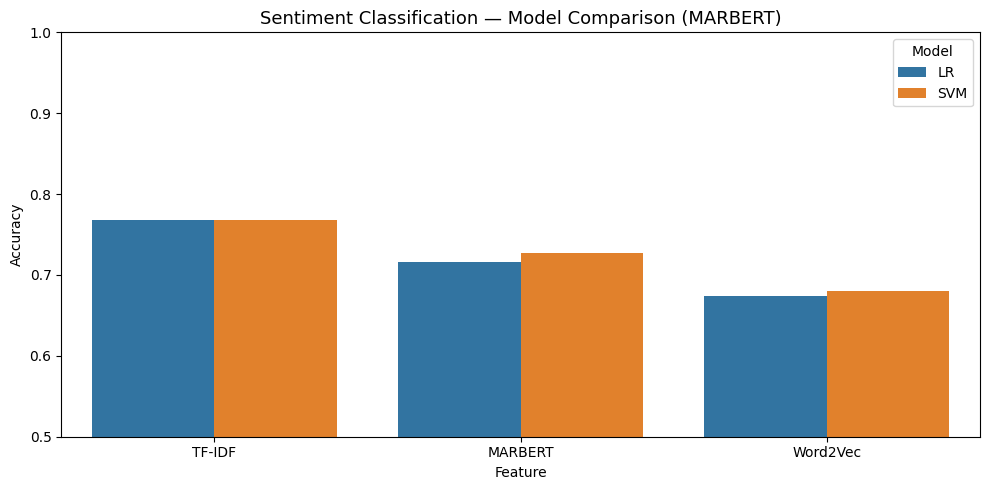

In [14]:
results = pd.DataFrame({
    'Feature': ['TF-IDF','TF-IDF','Word2Vec','Word2Vec','MARBERT','MARBERT'],
    'Model':   ['LR','SVM','LR','SVM','LR','SVM'],
    'Accuracy':[acc_tfidf_lr, acc_tfidf_svm, acc_w2v_lr, acc_w2v_svm, acc_bert_lr, acc_bert_svm]
})
results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
display(results)

plt.figure(figsize=(10,5))
sns.barplot(data=results, x='Feature', y='Accuracy', hue='Model')
plt.title('Sentiment Classification — Model Comparison (MARBERT)', fontsize=13)
plt.ylim(0.5, 1); plt.tight_layout(); plt.show()

## 🚀 Multi-Task MARBERT Fine-Tuning
### يتعلم المشاعر واللهجة في نفس الوقت

In [15]:

le_sent = LabelEncoder()
le_dial = LabelEncoder()
df['label_s'] = le_sent.fit_transform(df['sentiment'])
df['label_d'] = le_dial.fit_transform(df['dialect'])

print('Sentiment mapping:', dict(zip(le_sent.classes_, le_sent.transform(le_sent.classes_))))
print('Dialect mapping:  ', dict(zip(le_dial.classes_, le_dial.transform(le_dial.classes_))))

NUM_SENT = len(le_sent.classes_)
NUM_DIAL = len(le_dial.classes_)
assert NUM_SENT == 3, f'المشاعر لازم تكون 3، الموجود: {NUM_SENT} -> {list(le_sent.classes_)}'
assert NUM_DIAL == 3, f'اللهجات لازم تكون 3، الموجود: {NUM_DIAL} -> {list(le_dial.classes_)}'

df['ds'] = df['dialect'] + '_' + df['sentiment']
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['ds'])
train_df, val_df  = train_test_split(train_df, test_size=0.1, random_state=SEED, stratify=train_df['ds'])
print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('\nTrain cross-tab:')
print(pd.crosstab(train_df['dialect'], train_df['sentiment']))


Sentiment mapping: {'إيجابي': 0, 'سلبي': 1, 'محايد': 2}
Dialect mapping:   {'Egyptian': 0, 'Jordanian': 1, 'Saudi': 2}
Train: 22,024 | Val: 2,448 | Test: 6,119

Train cross-tab:
sentiment  إيجابي  سلبي  محايد
dialect                       
Egyptian     3697  3274    225
Jordanian    2180   648   2656
Saudi        3162  1012   5170


In [17]:

BATCH_SIZE = 16 if torch.cuda.is_available() else 8
MAX_LEN    = 160

class ArabicDataset(Dataset):
    def __init__(self, texts, s_labels, d_labels, tokenizer, max_len):
        self.texts    = list(texts)
        self.s_labels = list(s_labels)
        self.d_labels = list(d_labels)
        self.tok      = tokenizer
        self.max_len  = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], padding='max_length', truncation=True,
                       max_length=self.max_len, return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'sentiment_label':torch.tensor(self.s_labels[idx], dtype=torch.long),
            'dialect_label':  torch.tensor(self.d_labels[idx], dtype=torch.long),
        }

tokenizer_ft = AutoTokenizer.from_pretrained(MODEL_NAME)

# مهم: Fine-tuning يستخدم bert_text الخفيف، وليس processed_text الذي يحتوي _NEG
train_ds = ArabicDataset(train_df['bert_text'], train_df['label_s'], train_df['label_d'], tokenizer_ft, MAX_LEN)
val_ds   = ArabicDataset(val_df['bert_text'],   val_df['label_s'],   val_df['label_d'],   tokenizer_ft, MAX_LEN)
test_ds  = ArabicDataset(test_df['bert_text'],  test_df['label_s'],  test_df['label_d'],  tokenizer_ft, MAX_LEN)

# Sampler يوازن المشاعر واللهجة معاً حتى لا يطغى كلاس على الثاني
combo_counts = train_df['ds'].value_counts().to_dict()
sample_weights = train_df['ds'].map(lambda x: 1.0 / combo_counts[x]).values
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Batches → Train:{len(train_loader)} | Val:{len(val_loader)} | Test:{len(test_loader)} | MAX_LEN:{MAX_LEN} | BATCH:{BATCH_SIZE}')


Batches → Train:1377 | Val:153 | Test:383 | MAX_LEN:160 | BATCH:16


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [18]:

import torch
from transformers import AutoModel

# تحميل MARBERT بطريقة transformers الرسمية
MODEL_NAME = 'UBC-NLP/MARBERTv2'
bert_base = AutoModel.from_pretrained(MODEL_NAME)
print('✅ تم تحميل BERT weights')

class MultiTaskMARBERT(nn.Module):
    def __init__(self, bert_model, num_sent, num_dial, dropout=0.25):
        super().__init__()
        self.bert = bert_model
        hidden = self.bert.config.hidden_size

        # المشترك: representation مشتركة بين المشاعر واللهجة، وليس label جديد
        self.shared = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )

        self.sentiment_head = nn.Sequential(
            nn.Linear(hidden, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_sent)
        )
        self.dialect_head = nn.Sequential(
            nn.Linear(hidden, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_dial)
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        z = self.shared(cls)
        return self.sentiment_head(z), self.dialect_head(z)

model_ft = MultiTaskMARBERT(bert_base, NUM_SENT, NUM_DIAL, dropout=0.25).to(device)
print(f'Parameters: {sum(p.numel() for p in model_ft.parameters()):,}')


✅ تم تحميل BERT weights
Parameters: 163,828,742


In [19]:
# ====== Imports الخاصة بالتدريب ======

import torch
import torch.nn as nn

from transformers import AdamW, get_linear_schedule_with_warmup

from sklearn.utils.class_weight import compute_class_weight

In [20]:

EPOCHS         = 8
LR             = 1e-5
SENT_WEIGHT    = 0.85   # المشاعر هي الهدف الأساسي
DIAL_WEIGHT    = 0.15   # اللهجة تساعد فقط وما تخرب تصنيف المشاعر
PATIENCE       = 2

no_decay = ['bias', 'LayerNorm.weight']
params = [
    {'params': [p for n,p in model_ft.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n,p in model_ft.named_parameters() if     any(nd in n for nd in no_decay)], 'weight_decay': 0.0},
]
optimizer    = AdamW(params, lr=LR)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.10)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# Class weights للمشاعر واللهجة
sent_weights = compute_class_weight('balanced', classes=np.arange(NUM_SENT), y=train_df['label_s'].values)
dial_weights = compute_class_weight('balanced', classes=np.arange(NUM_DIAL), y=train_df['label_d'].values)
criterion_s  = nn.CrossEntropyLoss(weight=torch.tensor(sent_weights, dtype=torch.float).to(device), label_smoothing=0.03)
criterion_d  = nn.CrossEntropyLoss(weight=torch.tensor(dial_weights, dtype=torch.float).to(device), label_smoothing=0.03)

print(f'Total steps: {total_steps} | Warmup: {warmup_steps}')
print('Sentiment weights:', dict(zip(le_sent.classes_, np.round(sent_weights, 3))))
print('Dialect weights:  ', dict(zip(le_dial.classes_, np.round(dial_weights, 3))))


Total steps: 11016 | Warmup: 1101
Sentiment weights: {'إيجابي': 0.812, 'سلبي': 1.488, 'محايد': 0.912}
Dialect weights:   {'Egyptian': 1.02, 'Jordanian': 1.339, 'Saudi': 0.786}


/usr/local/lib/python3.12/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [21]:

def _metrics(y_true, y_pred):
    return {
        'acc': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted')
    }

def train_one_epoch(model, loader):
    model.train()
    total_loss, sp, dp, st, dt = 0, [], [], [], []
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        sl   = batch['sentiment_label'].to(device)
        dl   = batch['dialect_label'].to(device)
        optimizer.zero_grad(set_to_none=True)
        s_log, d_log = model(ids, mask)
        loss = SENT_WEIGHT * criterion_s(s_log, sl) + DIAL_WEIGHT * criterion_d(d_log, dl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
        sp.extend(s_log.argmax(1).detach().cpu().numpy()); st.extend(sl.detach().cpu().numpy())
        dp.extend(d_log.argmax(1).detach().cpu().numpy()); dt.extend(dl.detach().cpu().numpy())
    sm, dm = _metrics(st, sp), _metrics(dt, dp)
    return total_loss/len(loader), sm, dm

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, sp, dp, st, dt = 0, [], [], [], []
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        sl   = batch['sentiment_label'].to(device)
        dl   = batch['dialect_label'].to(device)
        s_log, d_log = model(ids, mask)
        loss = SENT_WEIGHT * criterion_s(s_log, sl) + DIAL_WEIGHT * criterion_d(d_log, dl)
        total_loss += loss.item()
        sp.extend(s_log.argmax(1).cpu().numpy()); st.extend(sl.cpu().numpy())
        dp.extend(d_log.argmax(1).cpu().numpy()); dt.extend(dl.cpu().numpy())
    sm, dm = _metrics(st, sp), _metrics(dt, dp)
    return total_loss/len(loader), sm, dm, st, sp, dt, dp


In [22]:

SAVE_PATH = BASE_PATH + 'marbert_multitask_best.pt'
history, best_val, bad_epochs = [], -1.0, 0

print('='*70)
print(f'  Fine-Tuning MARBERT — up to {EPOCHS} epochs | EarlyStopping patience={PATIENCE}')
print('='*70)

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_s, tr_d = train_one_epoch(model_ft, train_loader)
    vl_loss, vl_s, vl_d, *_ = evaluate(model_ft, val_loader)
    elapsed = time.time() - t0

    monitor = vl_s['macro_f1']  # أهم من accuracy لأنه يكشف ضعف الكلاسات الصغيرة
    history.append({
        'epoch':epoch, 'tr_loss':tr_loss, 'vl_loss':vl_loss,
        'tr_s':tr_s['acc'], 'vl_s':vl_s['acc'], 'tr_s_f1':tr_s['macro_f1'], 'vl_s_f1':vl_s['macro_f1'],
        'tr_d':tr_d['acc'], 'vl_d':vl_d['acc'], 'tr_d_f1':tr_d['macro_f1'], 'vl_d_f1':vl_d['macro_f1'],
    })

    print(f'Epoch {epoch}/{EPOCHS} [{elapsed:.0f}s]')
    print(f"  Train → Loss:{tr_loss:.4f} | Sent Acc:{tr_s['acc']:.4f} F1:{tr_s['macro_f1']:.4f} | Dial Acc:{tr_d['acc']:.4f} F1:{tr_d['macro_f1']:.4f}")
    print(f"  Val   → Loss:{vl_loss:.4f} | Sent Acc:{vl_s['acc']:.4f} F1:{vl_s['macro_f1']:.4f} | Dial Acc:{vl_d['acc']:.4f} F1:{vl_d['macro_f1']:.4f}")

    if monitor > best_val:
        best_val = monitor
        bad_epochs = 0
        torch.save({
            'model_state_dict': model_ft.state_dict(),
            'le_sent_classes': le_sent.classes_,
            'le_dial_classes': le_dial.classes_,
            'max_len': MAX_LEN,
            'model_name': MODEL_NAME,
        }, SAVE_PATH)
        print(f'  ✅ Saved! Best Val Sentiment Macro-F1: {best_val:.4f}')
    else:
        bad_epochs += 1
        print(f'  لم يتحسن Macro-F1 | bad_epochs={bad_epochs}/{PATIENCE}')
        if bad_epochs >= PATIENCE:
            print('  ⏹️ Early stopping')
            break

print(f'\n🏆 Best Val Sentiment Macro-F1: {best_val:.4f}')


  Fine-Tuning MARBERT — up to 8 epochs | EarlyStopping patience=2
Epoch 1/8 [149s]
  Train → Loss:0.8370 | Sent Acc:0.5878 F1:0.5813 | Dial Acc:0.5889 F1:0.5825
  Val   → Loss:0.6924 | Sent Acc:0.7259 F1:0.7214 | Dial Acc:0.8337 F1:0.8290
  ✅ Saved! Best Val Sentiment Macro-F1: 0.7214
Epoch 2/8 [149s]
  Train → Loss:0.4446 | Sent Acc:0.8503 F1:0.8498 | Dial Acc:0.8640 F1:0.8639
  Val   → Loss:0.5932 | Sent Acc:0.8141 F1:0.8099 | Dial Acc:0.8734 F1:0.8685
  ✅ Saved! Best Val Sentiment Macro-F1: 0.8099
Epoch 3/8 [148s]
  Train → Loss:0.3285 | Sent Acc:0.9060 F1:0.9058 | Dial Acc:0.9089 F1:0.9088
  Val   → Loss:0.5776 | Sent Acc:0.8415 F1:0.8382 | Dial Acc:0.8717 F1:0.8697
  ✅ Saved! Best Val Sentiment Macro-F1: 0.8382
Epoch 4/8 [148s]
  Train → Loss:0.2669 | Sent Acc:0.9341 F1:0.9337 | Dial Acc:0.9287 F1:0.9289
  Val   → Loss:0.6513 | Sent Acc:0.8248 F1:0.8211 | Dial Acc:0.9032 F1:0.8986
  لم يتحسن Macro-F1 | bad_epochs=1/2
Epoch 5/8 [148s]
  Train → Loss:0.2273 | Sent Acc:0.9551 F1:0.95

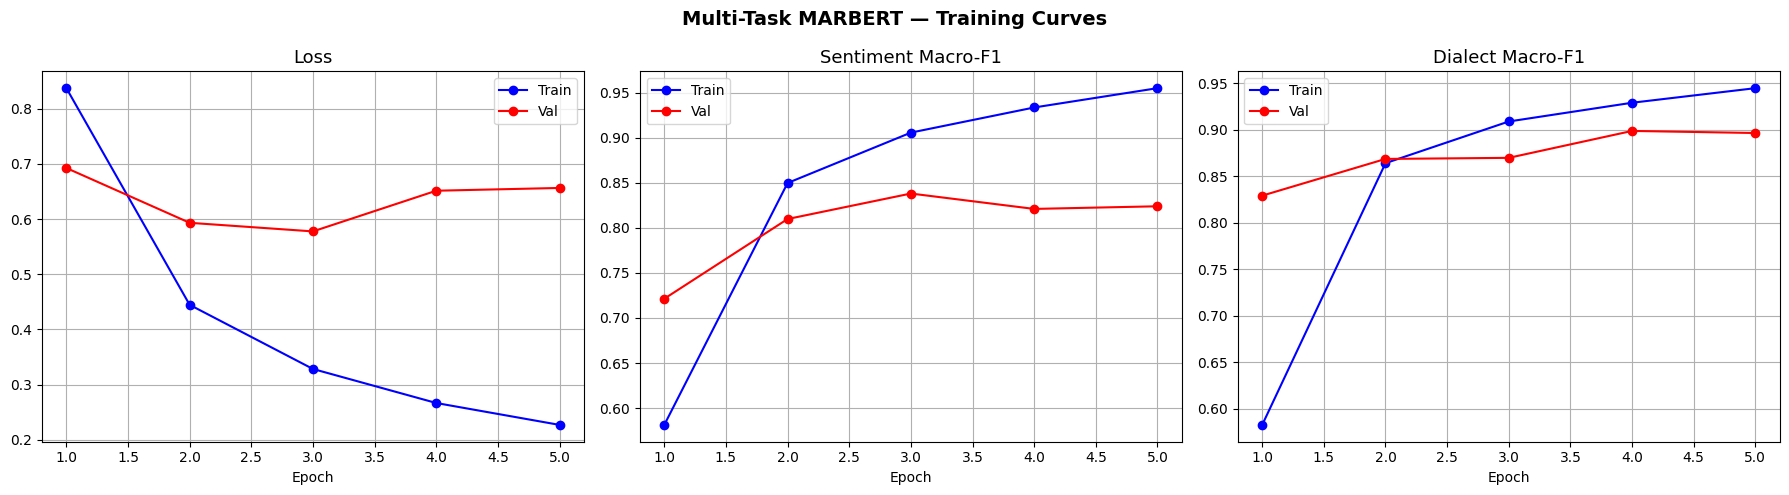

In [23]:

hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (tr, vl, title) in zip(axes, [
    ('tr_loss','vl_loss','Loss'),
    ('tr_s_f1','vl_s_f1','Sentiment Macro-F1'),
    ('tr_d_f1','vl_d_f1','Dialect Macro-F1')]):
    ax.plot(hist_df['epoch'], hist_df[tr], 'b-o', label='Train')
    ax.plot(hist_df['epoch'], hist_df[vl], 'r-o', label='Val')
    ax.set_title(title, fontsize=13); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True)
plt.suptitle('Multi-Task MARBERT — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [24]:

ckpt = torch.load(SAVE_PATH, map_location=device)
model_ft.load_state_dict(ckpt['model_state_dict'])
_, test_sm, test_dm, sent_true, sent_pred, dial_true, dial_pred = evaluate(model_ft, test_loader)
test_s = test_sm['acc']
test_d = test_dm['acc']

print('='*60)
print('  MULTI-TASK MARBERT — TEST RESULTS')
print('='*60)
print(f"Sentiment Accuracy : {test_sm['acc']:.4f}")
print(f"Sentiment Macro-F1 : {test_sm['macro_f1']:.4f}")
print(f"Dialect   Accuracy : {test_dm['acc']:.4f}")
print(f"Dialect   Macro-F1 : {test_dm['macro_f1']:.4f}")
print('\n── Sentiment Report ──')
print(classification_report(sent_true, sent_pred, target_names=le_sent.classes_))
print('\n── Dialect Report ──')
print(classification_report(dial_true, dial_pred, target_names=le_dial.classes_))


/tmp/ipykernel_7392/159209527.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(SAVE_PATH, map_location=device)


  MULTI-TASK MARBERT — TEST RESULTS
Sentiment Accuracy : 0.8348
Sentiment Macro-F1 : 0.8325
Dialect   Accuracy : 0.8802
Dialect   Macro-F1 : 0.8783

── Sentiment Report ──
              precision    recall  f1-score   support

      إيجابي       0.88      0.81      0.84      2511
        سلبي       0.80      0.83      0.82      1371
       محايد       0.81      0.87      0.84      2237

    accuracy                           0.83      6119
   macro avg       0.83      0.84      0.83      6119
weighted avg       0.84      0.83      0.83      6119


── Dialect Report ──
              precision    recall  f1-score   support

    Egyptian       0.95      0.94      0.95      1999
   Jordanian       0.73      0.93      0.82      1523
       Saudi       0.94      0.81      0.87      2597

    accuracy                           0.88      6119
   macro avg       0.88      0.89      0.88      6119
weighted avg       0.89      0.88      0.88      6119



In [25]:
# ==============================
# 💾 حفظ المودل على Google Drive
# ==============================
import pickle, torch

SAVE_DIR = '/content/drive/MyDrive/sentiment_data/sentiment_data/'

torch.save(model_ft.state_dict(), SAVE_DIR + 'model_ft.pt')

with open(SAVE_DIR + 'le_sent.pkl', 'wb') as f:
    pickle.dump(le_sent, f)

with open(SAVE_DIR + 'le_dial.pkl', 'wb') as f:
    pickle.dump(le_dial, f)

print('✅ تم الحفظ في:', SAVE_DIR)

RuntimeError: Parent directory /content/drive/MyDrive/sentiment_data/sentiment_data does not exist.

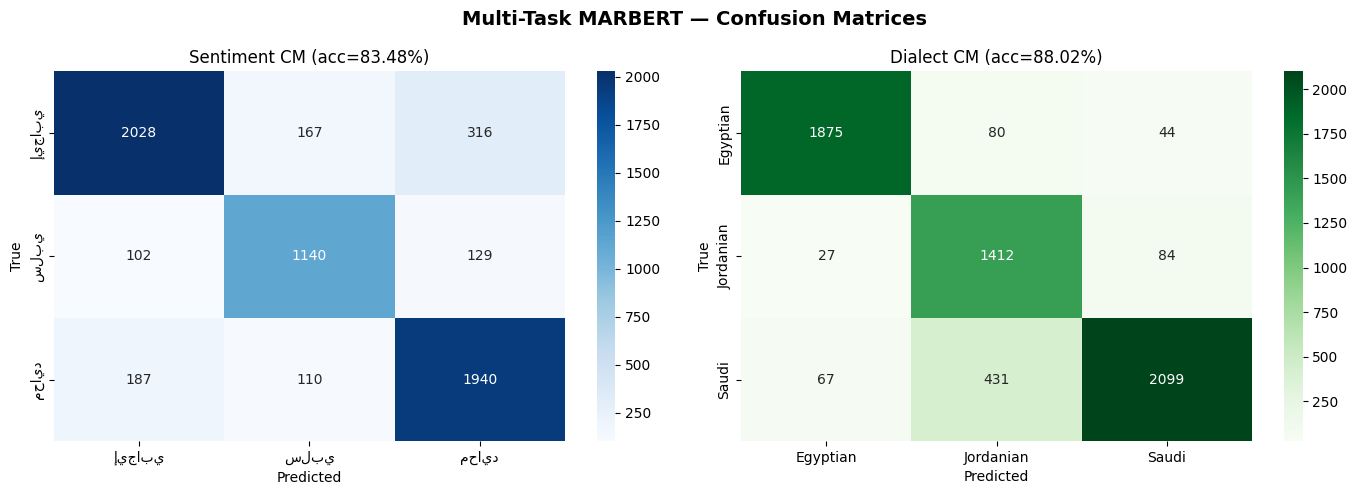

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_s = confusion_matrix(sent_true, sent_pred)
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le_sent.classes_, yticklabels=le_sent.classes_)
axes[0].set_title(f'Sentiment CM (acc={test_s:.2%})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_d = confusion_matrix(dial_true, dial_pred)
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=le_dial.classes_, yticklabels=le_dial.classes_)
axes[1].set_title(f'Dialect CM (acc={test_d:.2%})')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('Multi-Task MARBERT — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [27]:

test_dialects = test_df['dialect'].values
print('الدقة و Macro-F1 حسب اللهجة:')
print('='*55)
emoji_map = {'Egyptian':'🇪🇬', 'Jordanian':'🇯🇴', 'Saudi':'🇸🇦', 'Lebanese':'🇱🇧'}
for dialect in list(le_dial.classes_):
    mask   = test_dialects == dialect
    st_d   = np.array(sent_true)[mask]
    sp_d   = np.array(sent_pred)[mask]
    acc    = accuracy_score(st_d, sp_d)
    mf1    = f1_score(st_d, sp_d, average='macro')
    emoji  = emoji_map.get(dialect,'')
    print(f'{emoji} {dialect:12} | Acc: {acc:.4f} | Macro-F1: {mf1:.4f} | n={mask.sum():,}')

# أمثلة الأخطاء تساعدك تعرف هل المشكلة من الداتا أو من الموديل
err = test_df.copy().reset_index(drop=True)
err['true_sentiment'] = le_sent.inverse_transform(sent_true)
err['pred_sentiment'] = le_sent.inverse_transform(sent_pred)
err['true_dialect'] = le_dial.inverse_transform(dial_true)
err['pred_dialect'] = le_dial.inverse_transform(dial_pred)
wrong = err[err['true_sentiment'] != err['pred_sentiment']][['text','dialect','true_sentiment','pred_sentiment','true_dialect','pred_dialect']]
print('\nأول 20 خطأ في المشاعر:')
display(wrong.head(20))


الدقة و Macro-F1 حسب اللهجة:
🇪🇬 Egyptian     | Acc: 0.8554 | Macro-F1: 0.7412 | n=1,999
🇯🇴 Jordanian    | Acc: 0.7886 | Macro-F1: 0.7484 | n=1,523
🇸🇦 Saudi        | Acc: 0.8460 | Macro-F1: 0.8111 | n=2,597

أول 20 خطأ في المشاعر:


,text,dialect,true_sentiment,pred_sentiment,true_dialect,pred_dialect
4,عدي على اصابعك \n١ تراب وغبره \n٢ زباله \n٣ زب...,Jordanian,محايد,سلبي,Jordanian,Jordanian
6,انا اقول براء يستحق الدايموند اكثر,Saudi,محايد,إيجابي,Saudi,Saudi
7,لاشمحصارلشيامحصاوشيادبعانانوحراما😂😂😂😂😂😂😂,Saudi,إيجابي,محايد,Saudi,Jordanian
10,‏‪9:18‬‏ والله بندريتا ظلم البنت,Saudi,محايد,سلبي,Saudi,Saudi
15,هل يوجد خط من الزمالك لمدينة نصر والعكس,Egyptian,سلبي,إيجابي,Egyptian,Egyptian
17,أنصح بيه جداً,Egyptian,إيجابي,محايد,Egyptian,Egyptian
24,ايام الطيبين,Jordanian,إيجابي,محايد,Jordanian,Jordanian
28,بس مشكلتهم التوصيل في أغلب المطاعم يوصل متأخر,Egyptian,إيجابي,سلبي,Egyptian,Egyptian
29,ساااررره\nاحبج هواي هواي \nبهالتاريخ المميز \n...,Jordanian,محايد,إيجابي,Jordanian,Jordanian
45,سيئ جدا ولا يوجد أى تقدير للعميل ودى اخر مره ا...,Egyptian,إيجابي,سلبي,Egyptian,Egyptian


In [28]:

print('='*75)
print('         FINAL COMPARISON')
print('='*75)
print(f"{'Model':<35} {'Sent Acc':>10} {'Sent F1':>10} {'Dial Acc':>10} {'Dial F1':>10}")
print('-'*75)
print(f"{'TF-IDF + LR':<35} {acc_tfidf_lr:>10.4f} {'N/A':>10} {'N/A':>10} {'N/A':>10}")
print(f"{'TF-IDF + SVM':<35} {acc_tfidf_svm:>10.4f} {'N/A':>10} {'N/A':>10} {'N/A':>10}")
print(f"{'Word2Vec + SVM':<35} {acc_w2v_svm:>10.4f} {'N/A':>10} {'N/A':>10} {'N/A':>10}")
print(f"{'MARBERT + SVM':<35} {acc_bert_svm:>10.4f} {'N/A':>10} {'N/A':>10} {'N/A':>10}")
print(f"{'Multi-Task MARBERT Fine-Tuned':<35} {test_sm['acc']:>10.4f} {test_sm['macro_f1']:>10.4f} {test_dm['acc']:>10.4f} {test_dm['macro_f1']:>10.4f}")
print('='*75)


         FINAL COMPARISON
Model                                 Sent Acc    Sent F1   Dial Acc    Dial F1
---------------------------------------------------------------------------
TF-IDF + LR                             0.7684        N/A        N/A        N/A
TF-IDF + SVM                            0.7681        N/A        N/A        N/A
Word2Vec + SVM                          0.6797        N/A        N/A        N/A
MARBERT + SVM                           0.7269        N/A        N/A        N/A
Multi-Task MARBERT Fine-Tuned           0.8348     0.8325     0.8802     0.8783


In [29]:
# ==============================
# 📂 تحميل المودل من Google Drive
# ==============================
import pickle, torch
from transformers import AutoModel

SAVE_DIR = '/content/drive/MyDrive/sentiment_data/sentiment_data/'

# تحميل الـ encoders
with open(SAVE_DIR + 'le_sent.pkl', 'rb') as f:
    le_sent = pickle.load(f)

with open(SAVE_DIR + 'le_dial.pkl', 'rb') as f:
    le_dial = pickle.load(f)

NUM_SENT = len(le_sent.classes_)
NUM_DIAL = len(le_dial.classes_)

# تحميل BERT base ثم بناء المودل بنفس البنية
bert_base = AutoModel.from_pretrained('UBC-NLP/MARBERTv2')

model_ft = MultiTaskMARBERT(
    bert_model=bert_base,
    num_sent=NUM_SENT,
    num_dial=NUM_DIAL,
    dropout=0.25
).to(device)

model_ft.load_state_dict(torch.load(SAVE_DIR + 'model_ft.pt', map_location=device))
model_ft.eval()

print('✅ تم تحميل المودل بنجاح!')
print('المشاعر:', le_sent.classes_)
print('اللهجات:', le_dial.classes_)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/sentiment_data/sentiment_data/le_sent.pkl'

## 🎨 واجهة Gradio التفاعلية

In [1]:
import re
import gradio as gr

SENT_AR = {'إيجابي':'إيجابي 😊', 'سلبي':'سلبي 😞', 'محايد':'محايد 😐'}
DIAL_AR = {'Egyptian':'مصري EG', 'Jordanian':'أردني JO', 'Saudi':'سعودي SA', 'Lebanese':'لبناني LB'}

def _tokens(text):
    return set(str(text).split())

def _has_phrase(text, phrases):
    t = str(text)
    return any(p in t for p in phrases)

# ====== كلمات لهجية قوية ======
EG_STRONG = {
    'النهارده','دلوقتي','دلوقت','اوي','أوي','عايز','عاوز','ازاي',
    'ايه','إيه','كده','كدا','بجد','خالص','فين','منين','امتي',
    'ليه','بتاع','وحش','زفت','زهقان','جامد','جامده'
}

JO_STRONG = {
    'مبارح','امبارح','هاد','هاي','هدول','شو','هسا','هلا','هلأ',
    'عنجد','كتير','بدي','منيح','زاكي','زلمه','زلمة','ولك',
    'ستو','منسف','بلاها','بلاش','يسعدك','يسعدلي','يخوي','يخويي'
}

SA_STRONG = {
    'وع','وش','ابي','أبي','ابغي','أبغى','يبي','ياخي','مره','مرة',
    'الحين','تو','توني','توه','موب','وشذا','وش ذا','وش هال',
    'قهر','تكفى','بالله'
}

SA_CONTEXT = {
    'اليوم','مستانس','ونس','مروق','روق','معصب','عصب',
    'طفشان','طفش','خايس','ضغطي','ضغط'
}

# ====== كلمات مشاعر ======
NEG_ROOTS = {
    'زعل','حزن','تعب','مخنوق','ضايق','تضايق','عصب','ضغط',
    'وجع','الم','ألم','سيئ','وحش','خايس','بشع','ضعيف','فشل',
    'خسر','كسر','خيبه','خيبة','مصيبه','مصيبة','كارثه','كارثة',
    'زفت','قهر','طفش','عيط','صيح','بكي'
}

POS_ROOTS = {
    'عجب','عجبني','حب','ممتاز','روعه','روعة','رائع','تجنن',
    'سعيد','فرح','بسط','ونس','روق','لذيذ','احسن','أحسن',
    'نجح','وفق','ابدع','أبدع','شكر','حلو','جميل','تمام','زين',
    'جامد','جامده'
}

STRONG_NEG_PHRASES = {
    'ما عجبني', 'ما عجبني ولا شي', 'ما عجبني ولا',
    'مو زين', 'مو كويس', 'وع', 'خايس',
    'مرتفع ضغطي', 'ضغطي مرتفع',
}

NEG_PHRASES = {
    'مرتفع ضغطي','ضغطي مرتفع','ما عجبني','مو زين',
    'زعلان','مو كويس','وع','خايس','معصب','معصبه','معصبة'
}

POS_PHRASES = {
    'مروق','مستانس','مستانسه','مستانسة',
    'مبسوطة','مبسوطه','مبسوط',
    'سعيد','جامد','جامده'
}

# ✅ كلمات النفي الصريح
NEGATION_WORDS = {'ما', 'مو', 'مش', 'مب', 'لا', 'مافي', 'مفيش', 'ليس', 'لم', 'لن'}

NEGATABLE_POS = {
    'حبيت', 'حب', 'احب', 'أحب', 'عجبني', 'عجبك', 'عجبه',
    'اعجبني', 'أعجبني', 'نجح', 'وفق', 'ابدع', 'أبدع',
    'جاء', 'زين', 'كويس', 'حلو', 'جميل', 'تمام',
}

def check_negated_positive(text):
    words = str(text).split()
    for i, w in enumerate(words):
        if w in NEGATION_WORDS and i + 1 < len(words):
            next_word = words[i+1]
            # مطابقة كاملة
            if next_word in NEGATABLE_POS:
                return True
            # ✅ مطابقة جزئية — الكلمة تبدأ بجذر إيجابي
            for root in NEGATABLE_POS:
                if next_word.startswith(root):
                    return True
    return False

def apply_sentiment_logic(text, cleaned, sent_label, sp):
    full = str(text) + ' ' + str(cleaned)
    toks = _tokens(cleaned)

    neg_idx = list(le_sent.classes_).index('سلبي')
    pos_idx = list(le_sent.classes_).index('إيجابي')

    # ✅ نفي صريح لكلمة إيجابية
    if check_negated_positive(cleaned):
        return 'سلبي', '100% (مُصحَّح — نفي كلمة إيجابية)'

    # ✅ عبارات سلبية قوية بدون شرط ثقة
    if _has_phrase(full, STRONG_NEG_PHRASES):
        return 'سلبي', '100% (مُصحَّح — نفي قوي)'

    if (toks & NEG_ROOTS) or _has_phrase(full, NEG_PHRASES):
        if sp[pos_idx] < 0.75:
            return 'سلبي', '100% (مُصحَّح بالكلمات)'

    if (toks & POS_ROOTS) or _has_phrase(full, POS_PHRASES):
        if sp[neg_idx] < 0.75:
            return 'إيجابي', '100% (مُصحَّح بالكلمات)'

    return sent_label, f'{sp.max():.1%}'



def bert_preprocess(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'#', ' ', text)
    text = normalize_arabic_light(text)
    text = normalize_tokens(text)
    text = split_negation(text)  # ✅
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def apply_dialect_logic(text, cleaned, model_label, model_conf):
    raw = normalize_arabic_light(str(text))
    toks = _tokens(cleaned) | _tokens(raw)

    eg_score = len(toks & EG_STRONG)
    jo_score = len(toks & JO_STRONG)
    sa_score = len(toks & SA_STRONG)

    if _has_phrase(raw, {'وش ذا','وش هال','ياخي','تكفى','بالله'}):
        sa_score += 2

    if 'اليوم' in toks and (toks & SA_CONTEXT):
        sa_score += 1

    if sa_score > 0 and sa_score >= eg_score and sa_score >= jo_score:
        return 'سعودي SA', '100% (كلمات سعودية قوية)'

    if eg_score > 0 and eg_score >= jo_score and eg_score >= sa_score:
        return 'مصري EG', '100% (كلمات مصرية قوية)'

    if jo_score > 0 and jo_score >= eg_score and jo_score >= sa_score:
        return 'أردني JO', '100% (كلمات أردنية قوية)'

    if 'عيط' in toks:
        return DIAL_AR.get(model_label, model_label), f'{model_conf:.1%}'

    if eg_score == 0 and jo_score == 0 and sa_score == 0:
        return 'مشترك 🌍', '— (لا توجد كلمات لهجية واضحة)'

    if model_conf < 0.55:
        return 'مشترك 🌍', f'{model_conf:.1%} (ثقة منخفضة)'

    return DIAL_AR.get(model_label, model_label), f'{model_conf:.1%}'

def analyze(text):
    if not str(text).strip():
        return '—', '—', '—', '—', '—'

    model_ft.eval()
    cleaned = bert_preprocess(text)

    enc = tokenizer_ft(
        cleaned,
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

    with torch.no_grad():
        s_log, d_log = model_ft(
            enc['input_ids'].to(device),
            enc['attention_mask'].to(device)
        )

    sp = torch.softmax(s_log, dim=1).cpu().numpy()[0]
    dp = torch.softmax(d_log, dim=1).cpu().numpy()[0]

    raw_sent_label = le_sent.classes_[sp.argmax()]
    dial_label = le_dial.classes_[dp.argmax()]

    sent_label, sent_conf = apply_sentiment_logic(text, cleaned, raw_sent_label, sp)
    dial_display, dial_conf = apply_dialect_logic(text, cleaned, dial_label, float(dp.max()))

    sent_breakdown = ' | '.join([
        f'{le_sent.classes_[i]}: {sp[i]:.1%}' for i in range(len(sp))
    ])
    sent_breakdown += f' | النص بعد التطبيع: {cleaned}'

    return sent_label, sent_conf, dial_display, dial_conf, sent_breakdown

examples = [
    ['جامد جدا'],
    ['جامده اوي'],
    ['منسف يخوي'],
    ['بلاها هلا'],
    ['وع الاكل خايس'],
    ['اليوم انا مرتفع ضغطي ومعصب'],
    ['اليوم انت مروق ومستانس'],
    ['مبسوطة مرة'],
    ['تعبان جدا من كل شي'],
    ['اعيط النهارده'],
    ['اعيط'],
    ['عيطت كتير مبارح'],
    ['ابي حل ياخي'],
    ['وش ذا التطبيق'],
    ['عايز أكل كويس النهارده'],
    ['التطبيق وحش جداً ومش بيشتغل'],
    ['ما حبيت الفيلم'],
    ['مو عجبني'],
    ['ما اعجبني ولا شي'],
]

with gr.Blocks(title='Arabic Dialect Sentiment Analysis — MARBERT', theme=gr.themes.Soft()) as demo:
    gr.Markdown('''
    # 🔍 محلل مشاعر اللهجات العربية
    ## أردني JO | مصري EG | سعودي SA
    *مبني على MARBERT Multi-Task Fine-Tuning + Root/Gender Normalization*
    ''')

    with gr.Row():
        with gr.Column(scale=2):
            text_in = gr.Textbox(label='النص', placeholder='اكتب النص هنا...', lines=3)
            btn = gr.Button('🔍 تحليل', variant='primary')
            gr.Examples(examples=examples, inputs=text_in)

        with gr.Column(scale=1):
            sent_out = gr.Textbox(label='المشاعر')
            sent_conf_out = gr.Textbox(label='الثقة في المشاعر')
            dial_out = gr.Textbox(label='اللهجة')
            dial_conf_out = gr.Textbox(label='الثقة في اللهجة')
            breakdown_out = gr.Textbox(label='توزيع احتمالات المشاعر + التطبيع')

    btn.click(
        fn=analyze,
        inputs=text_in,
        outputs=[sent_out, sent_conf_out, dial_out, dial_conf_out, breakdown_out]
    )

    text_in.submit(
        fn=analyze,
        inputs=text_in,
        outputs=[sent_out, sent_conf_out, dial_out, dial_conf_out, breakdown_out]
    )

demo.launch(share=True, debug=True)

/tmp/ipykernel_1288/1946314422.py:225: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title='Arabic Dialect Sentiment Analysis — MARBERT', theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://099010a21382e7d2a0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://099010a21382e7d2a0.gradio.live
